# Chest X-Ray Classification using CNN (MobileNet)

Implementation based on the provided Kaggle reference notebook with adaptations for local execution and evaluation.

## Importing Required Libraries

In [1]:
# Import Required Libraries

import os
import random
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import imageio

import tensorflow as tf

from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Dataset Exploration

In [2]:
# Dataset Paths

base_dir = "../archive/chest_xray/"

train_pneumonia_dir = base_dir + "train/PNEUMONIA/"
train_normal_dir = base_dir + "train/NORMAL/"

test_pneumonia_dir = base_dir + "test/PNEUMONIA/"
test_normal_dir = base_dir + "test/NORMAL/"

val_pneumonia_dir = base_dir + "val/PNEUMONIA/"
val_normal_dir = base_dir + "val/NORMAL/"

In [3]:
# Reading Image Paths

train_pn = [
    train_pneumonia_dir + i
    for i in os.listdir(train_pneumonia_dir)
]

train_normal = [
    train_normal_dir + i
    for i in os.listdir(train_normal_dir)
]

test_pn = [
    test_pneumonia_dir + i
    for i in os.listdir(test_pneumonia_dir)
]

test_normal = [
    test_normal_dir + i
    for i in os.listdir(test_normal_dir)
]

val_pn = [
    val_pneumonia_dir + i
    for i in os.listdir(val_pneumonia_dir)
]

val_normal = [
    val_normal_dir + i
    for i in os.listdir(val_normal_dir)
]

print("Total Images:",
      len(train_pn + train_normal +
          test_pn + test_normal +
          val_pn + val_normal))

print("Total Pneumonia Images:",
      len(train_pn + test_pn + val_pn))

print("Total Normal Images:",
      len(train_normal + test_normal + val_normal))

Total Images: 5856
Total Pneumonia Images: 4273
Total Normal Images: 1583


## Dataset Splitting

In [4]:
# Dataset Splitting
# Train: 80%
# Test: 15%
# Validation: 5%

pn = train_pn + test_pn + val_pn
normal = train_normal + test_normal + val_normal

train_imgs = pn[:3418] + normal[:1224]

test_imgs = pn[3418:4059] + normal[1224:1502]

val_imgs = pn[4059:] + normal[1502:]

print("Total Train Images:",
      len(train_imgs))

print("Total Test Images:",
      len(test_imgs))

print("Total Validation Images:",
      len(val_imgs))

Total Train Images: 4642
Total Test Images: 919
Total Validation Images: 295


In [5]:
# Shuffle Images

random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_imgs)

print("Dataset shuffled successfully.")

Dataset shuffled successfully.


## Image Preprocessing

In [6]:
# Image Preprocessing

img_size = 224

def preprocess_image(image_list):

    X = []   # Images
    y = []   # Labels

    count = 0

    for image in image_list:
        try:
            # Read image in grayscale
            img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)

            # Resize image
            img = cv2.resize(
                img,
                (img_size, img_size),
                interpolation=cv2.INTER_CUBIC
            )

            # Convert grayscale to 3-channel image
            img = np.dstack([img, img, img])

            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Normalize image
            img = img.astype(np.float32) / 255.0

            X.append(img)
            count += 1

        except:
            continue

        # Labels
        if 'NORMAL' in image:
            y.append(0)

        elif ('virus' in image) or ('bacteria' in image):
            y.append(1)

    return X,y

## Preprocessing Training Images

In [7]:
# Preprocess Training Images

X, y = preprocess_image(train_imgs)

print("Training Images Processed:", len(X))
print("Training Labels:", len(y))

Training Images Processed: 4642
Training Labels: 4642


## Training Label Distribution

In [8]:
# Check Label Distribution

arr = y
uniqueValues, occurCount = np.unique(arr, return_counts=True)

print("Unique Values:", uniqueValues)
print("Occurrence Count:", occurCount)

Unique Values: [0 1]
Occurrence Count: [1224 3418]


## Displaying Sample Training Images

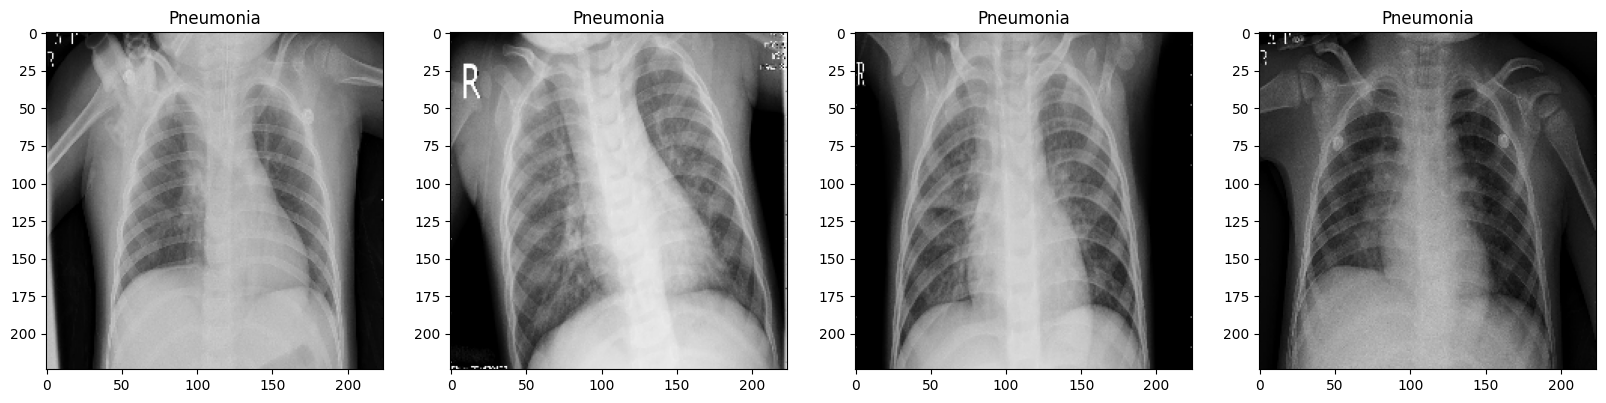

In [9]:
# Display Sample Training Images

fig = plt.figure(figsize=(20, 5))
k = 1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if y[i] == 0:
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
    plt.imshow(X[i])
    k += 1
plt.show()

## Preprocessing Test Images

In [10]:
# Preprocess Test Images

P, t = preprocess_image(test_imgs)
print("Test Images Processed:", len(P))
print("Test Labels:", len(t))

Test Images Processed: 919
Test Labels: 919


## Test Label Distribution

In [11]:
# Test Label Distribution

arr = t

uniqueValues, occurCount = np.unique(arr, return_counts=True)

print("Unique Values:", uniqueValues)
print("Occurrence Count:", occurCount)

Unique Values: [0 1]
Occurrence Count: [278 641]


## Displaying Sample Test Images

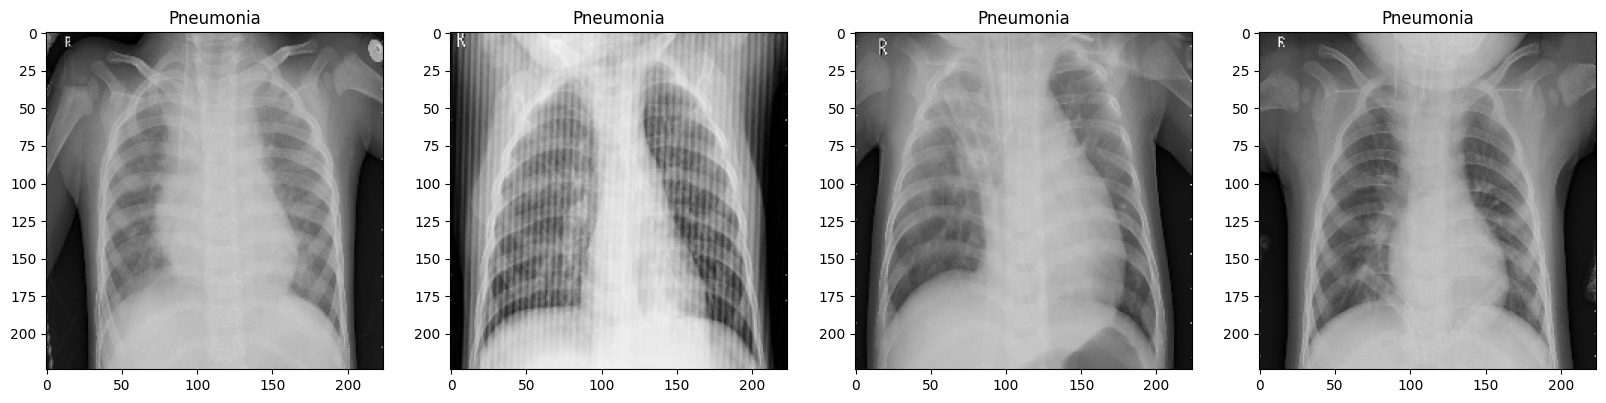

In [12]:
# Display Sample Test Images

fig = plt.figure(figsize=(20, 5))
k = 1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if t[i] == 0:
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
    plt.imshow(P[i])
    k += 1
plt.show()

## Preprocessing Validation Images

In [13]:
# Preprocess Validation Images

K, m = preprocess_image(val_imgs)

print("Validation Images Processed:", len(K))
print("Validation Labels:", len(m))

Validation Images Processed: 295
Validation Labels: 295


## Validation Label Distribution

In [14]:
# Validation Label Distribution

arr = m

uniqueValues, occurCount = np.unique(arr, return_counts=True)

print("Unique Values:", uniqueValues)
print("Occurrence Count:", occurCount)

Unique Values: [0 1]
Occurrence Count: [ 81 214]


## Displaying Sample Validation Images

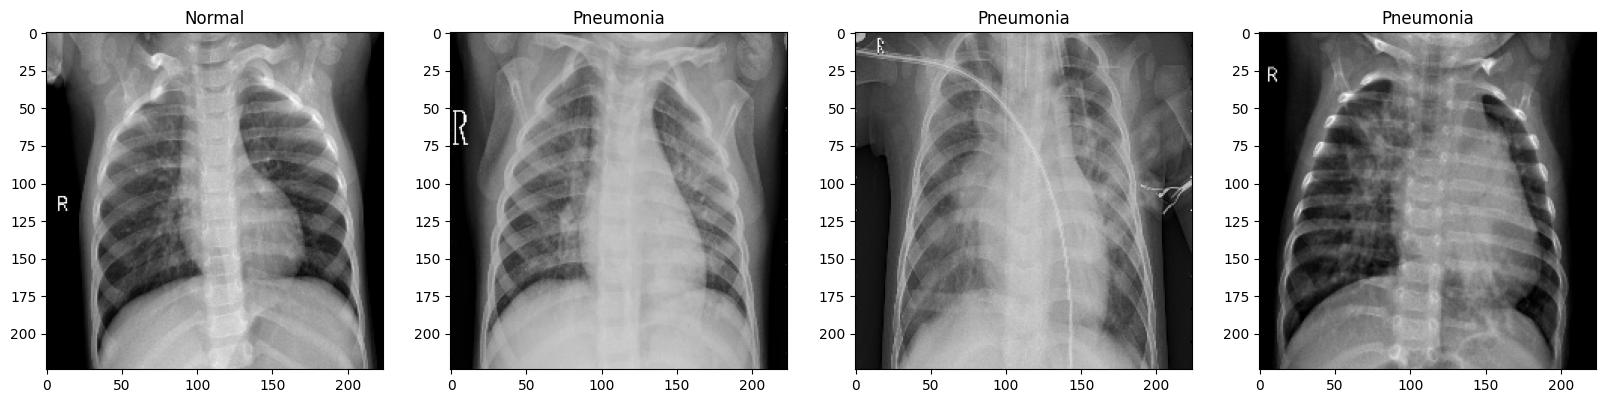

In [15]:
# Display Sample Validation Images

fig = plt.figure(figsize=(20, 5))
k = 1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if m[i] == 0:
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
    plt.imshow(K[i])
    k += 1
plt.show()

## Class Distribution Visualization

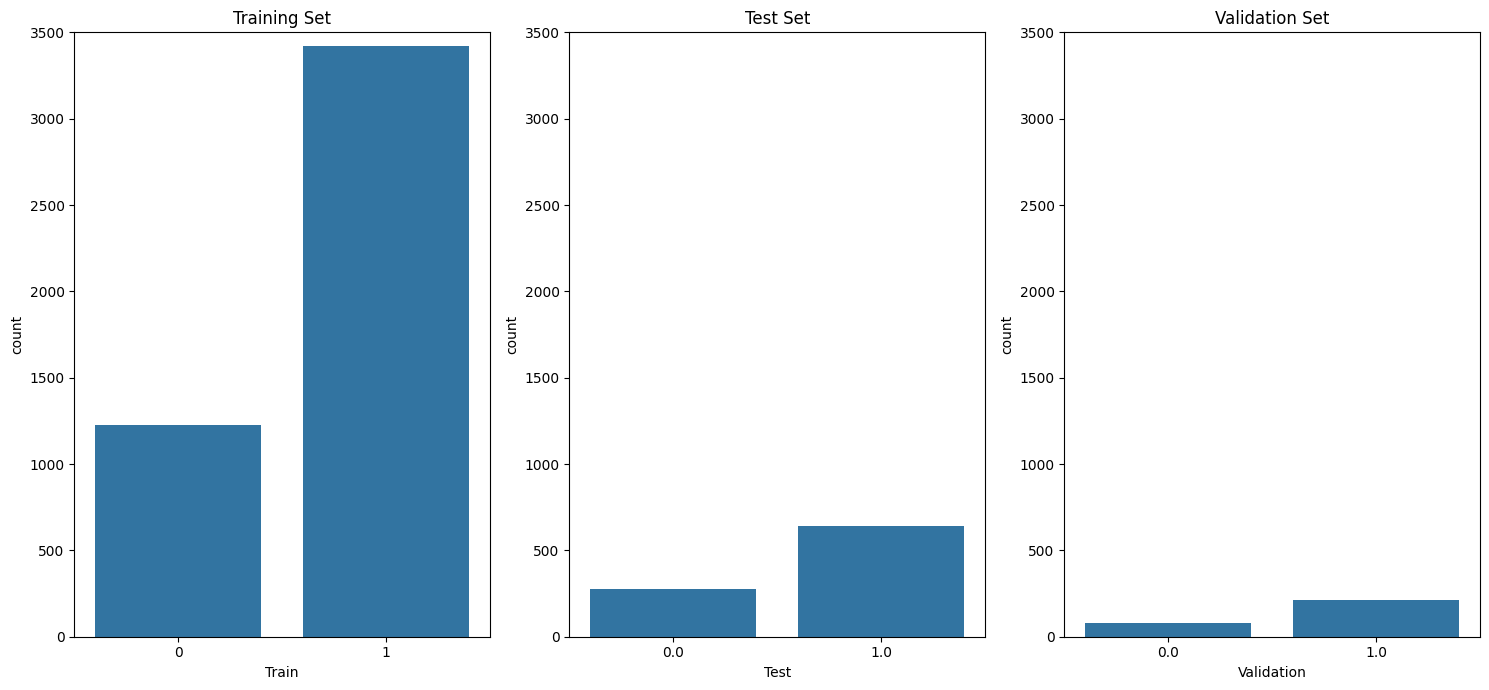

In [16]:
# Visualizing Class Distribution

df = pd.DataFrame()

df['Train'] = pd.Series(y)
df['Test'] = pd.Series(t)
df['Validation'] = pd.Series(m)

fig, ax = plt.subplots(1, 3, figsize=(15, 7))

sns.countplot(x=df['Train'], ax=ax[0])
ax[0].set_title("Training Set")
ax[0].set_ylim(0, 3500)

sns.countplot(x=df['Test'], ax=ax[1])
ax[1].set_title("Test Set")
ax[1].set_ylim(0, 3500)

sns.countplot(x=df['Validation'], ax=ax[2])
ax[2].set_title("Validation Set")
ax[2].set_ylim(0, 3500)

plt.tight_layout()
plt.show()

## Computing Class Weights

In [17]:
# Compute Class Weights

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(1.8962418300653594), 1: np.float64(0.679052077238151)}


## Converting Data to NumPy Arrays

In [18]:
# Convert to NumPy Arrays

X_train = np.array(X)
y_train = np.array(y)

X_test = np.array(P)
y_test = np.array(t)

X_val = np.array(K)
y_val = np.array(m)

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

print("X_val Shape:", X_val.shape)
print("y_val Shape:", y_val.shape)

X_train Shape: (4642, 224, 224, 3)
y_train Shape: (4642,)
X_test Shape: (919, 224, 224, 3)
y_test Shape: (919,)
X_val Shape: (295, 224, 224, 3)
y_val Shape: (295,)


## Memory Cleanup and Batch Configuration

In [19]:
# Memory Cleanup

del X
del y
gc.collect()

# Dataset Sizes

ntrain = len(X_train)
nval = len(X_val)
batch_size = 32
print("Training Samples:", ntrain)
print("Validation Samples:", nval)
print("Batch Size:", batch_size)

Training Samples: 4642
Validation Samples: 295
Batch Size: 32


## Data Augmentation

In [20]:
# Data Augmentation

train_datagen = ImageDataGenerator(
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.2,
    zoom_range=0.45,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    zoom_range=0.45
)

## Creating Image Generators

In [21]:
# Create Image Generators

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=batch_size
)

val_generator = val_datagen.flow(
    X_val,
    y_val,
    batch_size=batch_size
)

print("Train Generator Created")
print("Validation Generator Created")

Train Generator Created
Validation Generator Created


## Building the MobileNet CNN Model

In [22]:
# MobileNet CNN Model

from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Image Size
img_size = 224

# Base MobileNet Model
base_model = MobileNet(
    weights=None,
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Add Global Average Pooling
x = base_model.output

x = GlobalAveragePooling2D()(x)

# Final Classification Layer
predictions = Dense(
    1,
    activation='sigmoid'
)(x)

# Final Model
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy', 'mae']
)

print("MobileNet Model Created Successfully")

MobileNet Model Created Successfully


## Training Callbacks

In [23]:
# Training Callbacks

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping
)

checkpoint = ModelCheckpoint(
    filepath="../Results/best_mobilenet_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Callbacks Created Successfully")

Callbacks Created Successfully


## Initial CNN Training

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.7542 - loss: 0.4793 - mae: 0.2756
Epoch 1: val_loss improved from None to 1.18161, saving model to ../Results/best_mobilenet_model.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - binary_accuracy: 0.8256 - loss: 0.3835 - mae: 0.2160 - val_binary_accuracy: 0.7292 - val_loss: 1.1816 - val_mae: 0.2769
Epoch 2/10
  1/145 ━━━━━━━━━━━━━━━━━━━━ 2:58 1s/step - binary_accuracy: 0.9062 - loss: 0.1681 - mae: 0.1338

c:\ML Projects\Medical-Image-Classification-Projects\Exersize-2(ChestXRay)\Code\.venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 1.18161
145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - binary_accuracy: 0.9062 - loss: 0.1681 - mae: 0.1338 - val_binary_accuracy: 0.7222 - val_loss: 1.2217 - val_mae: 0.2834
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.8801 - loss: 0.2892 - mae: 0.1586
Epoch 3: val_loss did not improve from 1.18161
145/145 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - binary_accuracy: 0.8816 - loss: 0.2776 - mae: 0.1567 - val_binary_accuracy: 0.7188 - val_loss: 1.6719 - val_mae: 0.2824
Epoch 4/10
  1/145 ━━━━━━━━━━━━━━━━━━━━ 3:02 1s/step - binary_accuracy: 0.8750 - loss: 0.2894 - mae: 0.1752
Epoch 4: val_loss did not improve from 1.18161
145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - binary_accuracy: 0.8750 - loss: 0.2894 - mae: 0.1752 - val_binary_accuracy: 0.7292 - val_loss: 1.6275 - val_mae: 0.2720
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.8900 - loss: 0.2637 - mae: 0.1428
Epoch 5: val_loss did not improve from 1.18161

## CNN Model Evaluation

In [25]:
# Model Predictions

preds = model.predict(X_test)

print("Predictions Generated Successfully")

29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step
Predictions Generated Successfully


## Performance Metrics

In [26]:
# Performance Metrics

acc = accuracy_score(
    y_test,
    np.round(preds)
) * 100

cm = confusion_matrix(
    y_test,
    np.round(preds)
)

tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX")
print(cm)

print("\nTEST METRICS")

precision = tp / (tp + fp) * 100

recall = tp / (tp + fn) * 100

specificity = tn / (tn + fp) * 100

f1_score = (
    2 * precision * recall
) / (precision + recall)

print(f"Accuracy: {acc:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Sensitivity (Recall): {recall:.2f}%")
print(f"Specificity: {specificity:.2f}%")
print(f"F1-score: {f1_score:.2f}%")

print("\nTRAIN METRICS")
print(
    "Train Accuracy:",
    round(history.history['binary_accuracy'][-1] * 100, 2)
)

CONFUSION MATRIX
[[271   7]
 [464 177]]

TEST METRICS
Accuracy: 48.75%
Precision: 96.20%
Sensitivity (Recall): 27.61%
Specificity: 97.48%
F1-score: 42.91%

TRAIN METRICS
Train Accuracy: 84.38


## Confusion Matrix Visualization

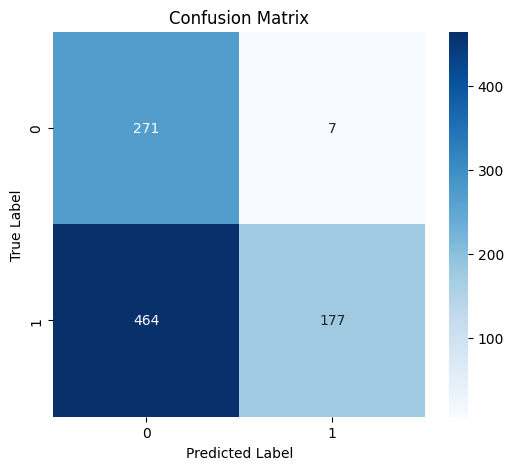

In [27]:
# Confusion Matrix Heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## ROC Curve and AUC Score

AUC Score: 0.8314908135893782


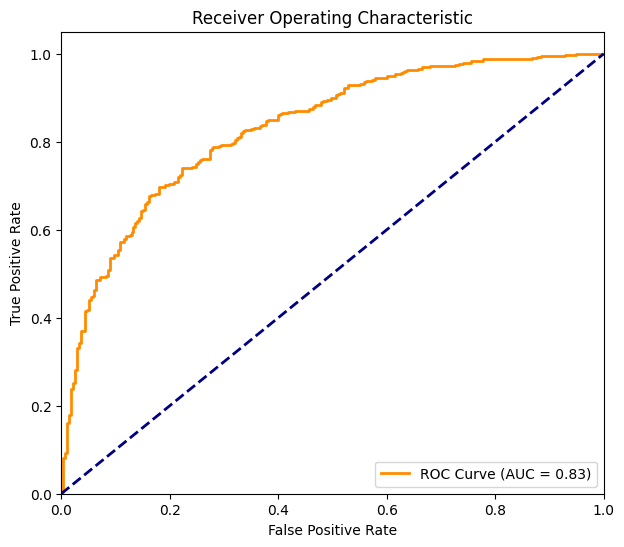

In [28]:
# ROC Curve and AUC Score

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    preds
)

auc_score = auc(fpr, tpr)

print("AUC Score:", auc_score)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'ROC Curve (AUC = {auc_score:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=2,
    linestyle='--'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Receiver Operating Characteristic')

plt.legend(loc="lower right")

plt.show()

## Training and Validation Curves

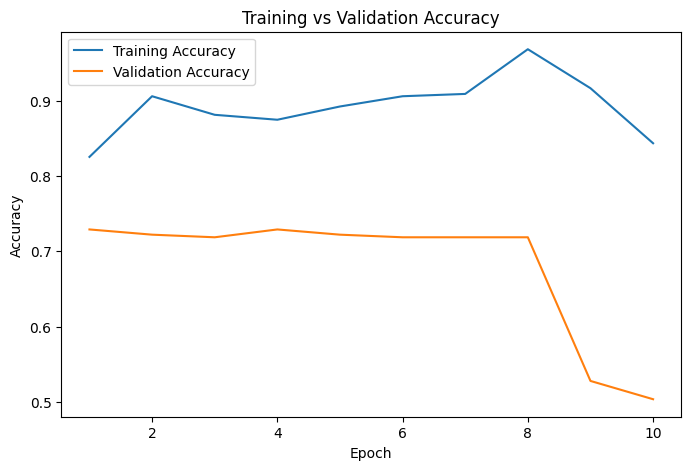

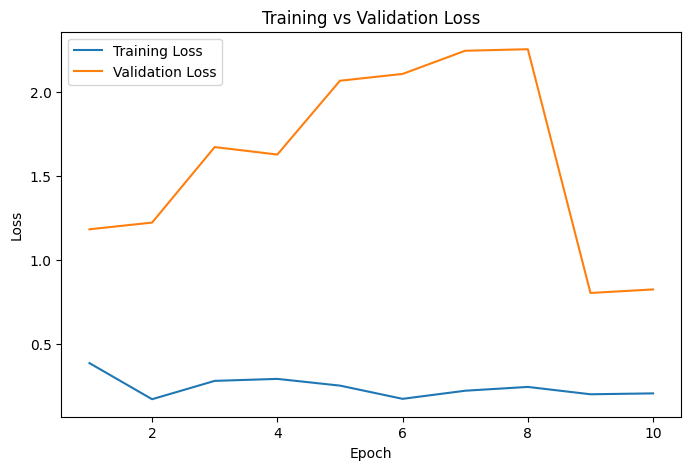

In [29]:
# Training Curves

acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']    
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(
    1,
    len(acc)+1
)

# Accuracy Plot

plt.figure(figsize=(8,5))
plt.plot(
    epochs,
    acc,
    label='Training Accuracy'
)
plt.plot(
    epochs,
    val_acc,
    label='Validation Accuracy'
)
plt.title(
    'Training vs Validation Accuracy'
)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot

plt.figure(figsize=(8,5))
plt.plot(
    epochs,
    loss,
    label='Training Loss'
)
plt.plot(
    epochs,
    val_loss,
    label='Validation Loss'
)
plt.title(
    'Training vs Validation Loss'
)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()